In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/guriya79/how-ai-is-changing-student-life/AI_Student_Life_Pakistan_2026.csv


# Role of AI in Pakistani Students lives

# EDA 
### Objectives:
how usage of AI is transforming students lives in Pakistan

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

print('libraries imported')

libraries imported


## Data Overview

In [3]:
df = pd.read_csv('/kaggle/input/datasets/guriya79/how-ai-is-changing-student-life/AI_Student_Life_Pakistan_2026.csv')
print(df.head())

   Student_ID  Age  Gender Education_Level     City AI_Tool_Used  \
0           1   15  Female          School   Lahore      ChatGPT   
1           2   15  Female         College   Multan      Copilot   
2           3   16  Female         College   Multan      ChatGPT   
3           4   22    Male      University  Karachi      ChatGPT   
4           5   16    Male          School   Multan      ChatGPT   

   Daily_Usage_Hours   Purpose Impact_on_Grades Satisfaction_Level  
0                0.8   Writing   Slight Decline                Low  
1                1.6  Learning        No Change               High  
2                1.8  Research         Improved                Low  
3                4.2  Learning         Improved               High  
4                1.8    Coding         Improved             Medium  


## Missing Value check

In [4]:
print(df.isna().sum())

Student_ID            0
Age                   0
Gender                0
Education_Level       0
City                  0
AI_Tool_Used          0
Daily_Usage_Hours     0
Purpose               0
Impact_on_Grades      0
Satisfaction_Level    0
dtype: int64


# Data Frame Information

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_ID          100 non-null    int64  
 1   Age                 100 non-null    int64  
 2   Gender              100 non-null    object 
 3   Education_Level     100 non-null    object 
 4   City                100 non-null    object 
 5   AI_Tool_Used        100 non-null    object 
 6   Daily_Usage_Hours   100 non-null    float64
 7   Purpose             100 non-null    object 
 8   Impact_on_Grades    100 non-null    object 
 9   Satisfaction_Level  100 non-null    object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.9+ KB
None


# Graphical Analysis for further EDA procedure

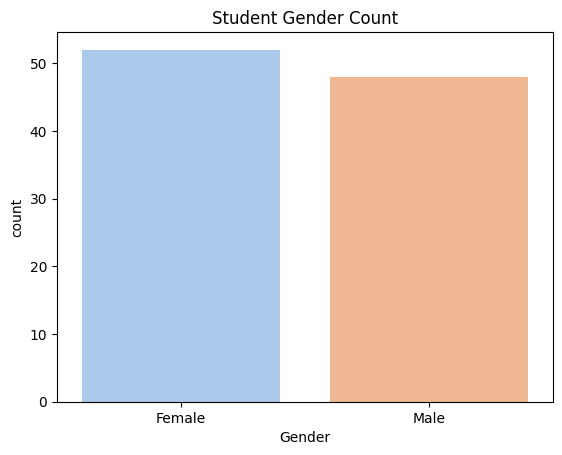

In [6]:
# gender distribution:
sns.countplot(data=df, x='Gender', palette='pastel', hue='Gender')

plt.title('Student Gender Count')
plt.show()

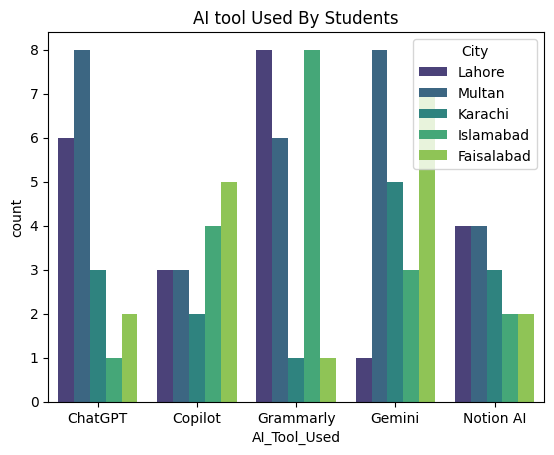

In [7]:
sns.countplot(data=df, x='AI_Tool_Used', palette='viridis', hue='City')

plt.title('AI tool Used By Students')
plt.show()

# Interpretation AI Tools Used By Students: 
This bar chart illustrates the market share of various AI platforms among the surveyed students. Gemini emerges as the most preferred tool, closely followed by ChatGPT and Grammarly. The relatively even distribution among the top tools indicates that students are not relying on a single monopoly; instead, they are adopting a diverse "tech stack" to meet varying academic needs, from drafting essays to solving complex logic problems.

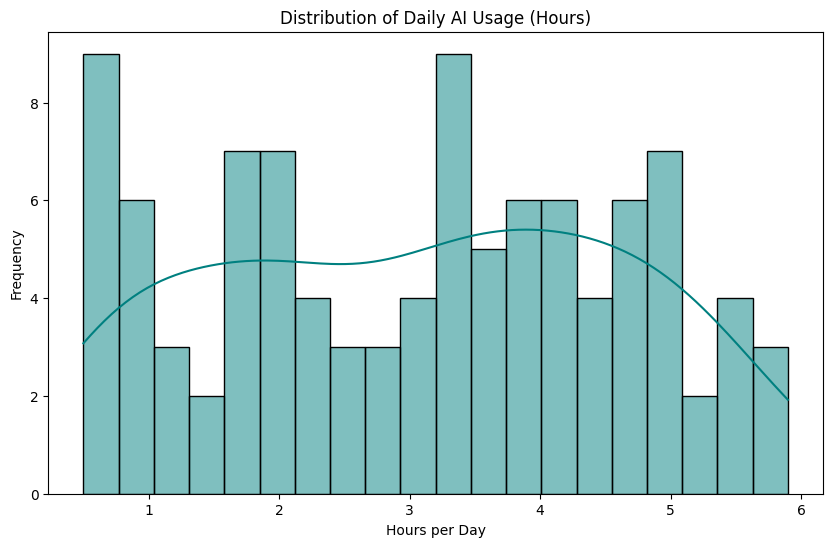

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Daily_Usage_Hours'], bins=20, kde=True, color='teal')
plt.title('Distribution of Daily AI Usage (Hours)')
plt.xlabel('Hours per Day')
plt.ylabel('Frequency')
plt.show()

# Interpretation Hours Per Day Usage: 
The histogram with a Kernel Density Estimate (KDE) curve shows how much time students spend with AI daily. While the overall average sits around 3 hours, the distribution reveals two main types of users: a large cluster spending 1 to 2 hours for quick queries or specific tasks, and a significant "heavy user" tail extending out to 4–5+ hours, likely representing students engaged in deep research, coding, or extensive writing assignments.

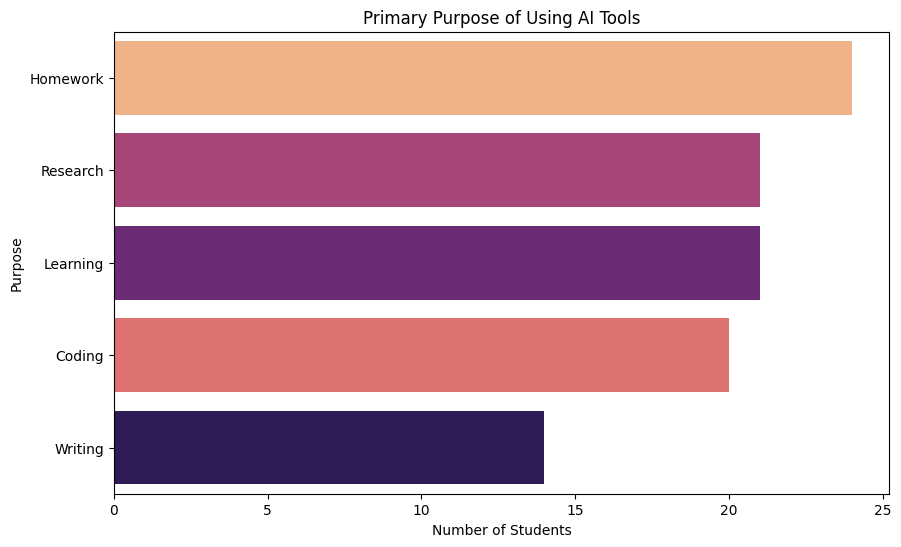

In [9]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Purpose', order=df['Purpose'].value_counts().index, palette='magma', hue='Purpose')
plt.title('Primary Purpose of Using AI Tools')
plt.xlabel('Number of Students')
plt.ylabel('Purpose')
plt.show()

# Interpretation: 
This horizontal bar chart breaks down the functional role AI plays in student life. "Homework" is the overwhelmingly dominant category, followed by "Learning" and "Research." This confirms that AI has effectively transitioned into the role of a 24/7 personal tutor and research assistant, handling the heavy lifting of daily academic deliverables rather than just being a novelty for side projects.

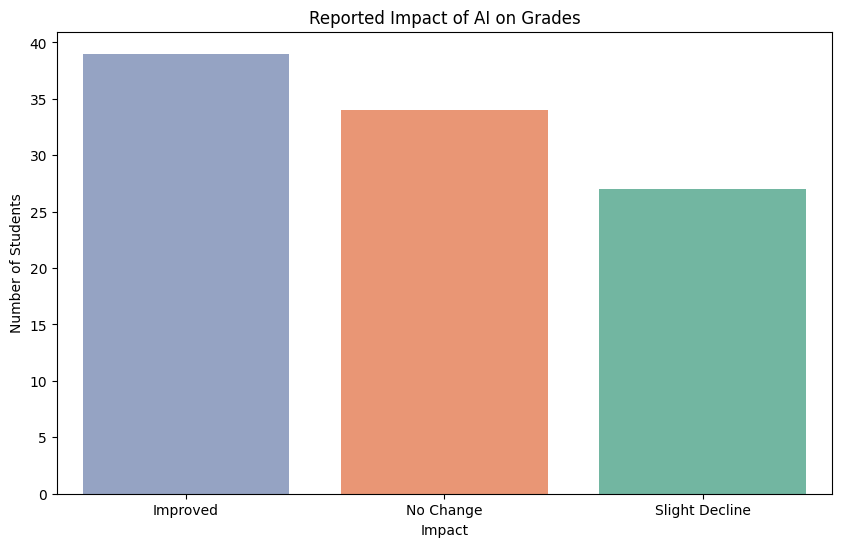

In [10]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Impact_on_Grades', order=df['Impact_on_Grades'].value_counts().index, palette='Set2', hue='Impact_on_Grades')
plt.title('Reported Impact of AI on Grades')
plt.xlabel('Impact')
plt.ylabel('Number of Students')
plt.show()

# Interpretation: 
This chart measures the academic ROI of using AI. While a plurality (39%) report that their grades have improved, a nearly equal segment (34%) reports no change, utilizing AI mostly as a time-saving convenience. Most notably, a significant minority (27%) report a "Slight Decline" in grades. This highlights a crucial learning curve: over-reliance on AI to bypass actual critical thinking—rather than using it to supplement learning—can negatively impact a student's actual comprehension and test performance.

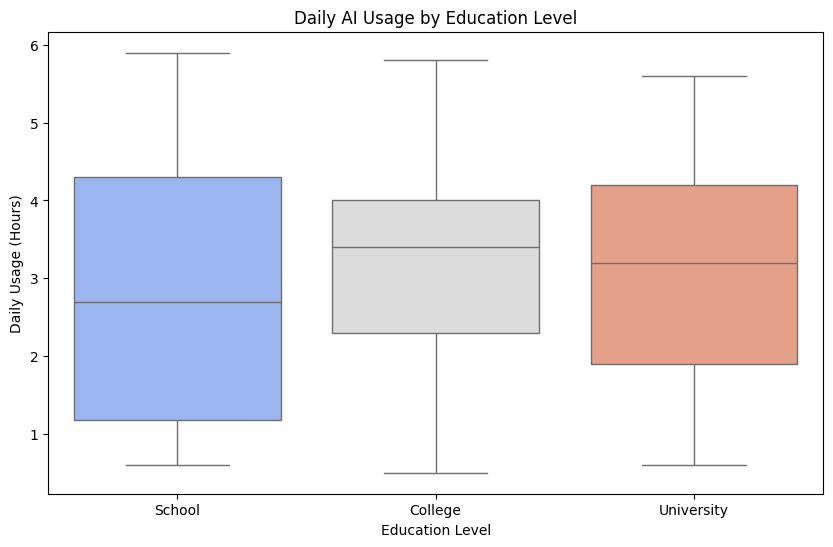

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Education_Level', y='Daily_Usage_Hours', palette='coolwarm', order=['School', 'College', 'University'], hue="Education_Level")
plt.title('Daily AI Usage by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Daily Usage (Hours)')
plt.show()

# Interpretation: 
The boxplot visualizes how reliance on AI scales with academic seniority. School-level students have a tighter, generally lower usage spread, reflecting more supervised or strictly structured assignments. In contrast, College and University students show much wider interquartile ranges and higher median usage times. This suggests that as the complexity and autonomy of coursework increase, students lean much more heavily on AI to manage their workload.

<Axes: xlabel='Impact_on_Grades', ylabel='Daily_Usage_Hours'>

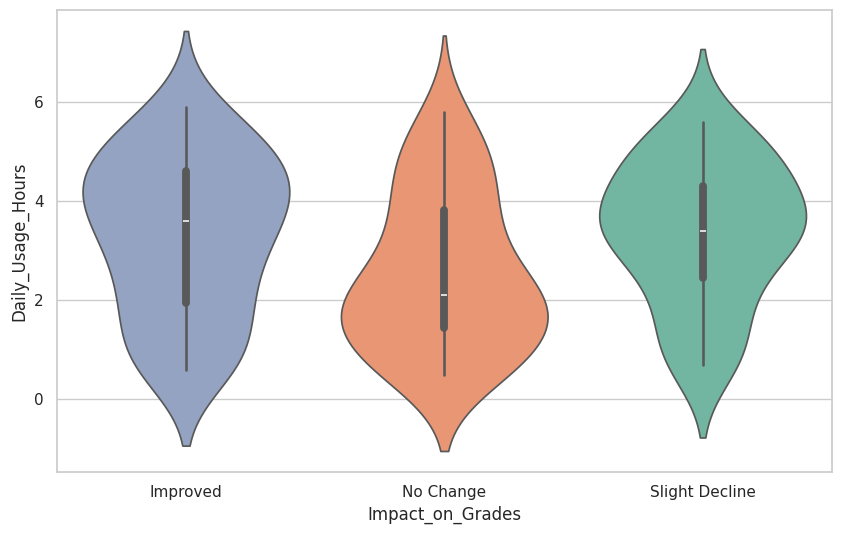

In [12]:
sns.set_theme(style="whitegrid")
# boxplot to show Daily Usage Hours across different Impacts on Grades
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df, 
    x='Impact_on_Grades', 
    y='Daily_Usage_Hours', 
    palette='Set2', 
    hue='Impact_on_Grades',
    order=['Improved', 'No Change', 'Slight Decline']
)

# Interpretation: 
This violinplot reveals a fascinating relationship between how much time students spend using AI tools and the actual outcome on their academic performance:

"Improved" Grades: Students who report improved grades tend to have a moderate and tightly clustered daily usage (often centering around 1.5 to 3.5 hours). This suggests that using AI strategically as a targeted supplement—rather than relying on it all day—yields the best academic results.

"Slight Decline" in Grades: Interestingly, students who report a slight decline in their grades often display significantly higher and more varied daily usage (with medians and upper quartiles stretching toward 4 to 5+ hours). This indicates that excessive reliance on AI might become a crutch, negatively impacting actual learning and academic performance.

"No Change": Those experiencing no change have a broader spread but generally hover in the middle, likely representing students who use AI for general convenience rather than intensive study sessions.

---

# Executive Summary: Role of AI in Pakistani Students' Lives

## Summary

This Exploratory Data Analysis examines how Artificial Intelligence is transforming the academic lives of Pakistani students. The dataset (AI_Student_Life_Pakistan_2026.csv) provides insights into AI adoption patterns, usage behaviors, and their correlation with academic outcomes. The analysis covers gender distribution, AI tool preferences, daily usage patterns, primary use cases, and the impact on academic performance across different education levels.

## Key Findings

### 1. **AI Tool Adoption & Market Share**
- **Gemini** emerges as the most preferred AI tool among students, closely followed by **ChatGPT** and **Grammarly**
- Students are adopting a diverse "tech stack" rather than relying on a single AI platform, demonstrating sophisticated tool utilization for varied academic needs
- This diversity reflects the understanding that different tools serve different purposes (writing, problem-solving, coding, etc.)

### 2. **Usage Duration Patterns**
- **Average daily usage: ~3 hours per day**
- Two distinct user segments identified:
  - **Light users (modal group)**: 1-2 hours daily for quick queries and specific tasks
  - **Heavy users (significant tail)**: 4-5+ hours daily, likely engaged in deep research, coding, or extensive writing
- Higher usage observed as students progress through education levels (School < College < University)

### 3. **Primary Use Cases**
- **Homework assistance** is the overwhelming dominant use case
- Secondary purposes include **Learning** and **Research**
- AI has successfully transitioned from a novelty tool to a **24/7 personal tutor and research assistant**
- Students are using AI for daily academic deliverables rather than supplementary tasks

### 4. **Academic Impact - Critical Finding**
- **39%** of students report **improved grades** through AI usage
- **34%** report **no change** in academic performance
- **27%** report a **slight decline** in grades
- This indicates a **critical learning curve**: strategic AI usage improves outcomes, while over-reliance can harm academic comprehension

### 5. **Usage Intensity vs. Academic Outcomes (Most Significant)**
- **Improved grades**: Correlated with **moderate usage (1.5-3.5 hours/day)** - tight, consistent patterns
- **Slight decline**: Associated with **excessive usage (4-5+ hours/day)** with high variability
- **No change**: Scattered usage patterns (middle range) - casual convenience usage without significant impact
- **Insight**: Quality and intentionality of AI usage matter more than quantity

### 6. **Education Level Stratification**
- **School students**: Lower, tightly clustered AI usage (more supervised/structured assignments)
- **College/University students**: Significantly higher usage (median and IQR), wider spreads indicating greater academic autonomy and workload complexity
- Clear escalation pattern reflecting increasing course complexity and independence at higher education levels

## Conclusion

**Key Takeaway**: AI is fundamentally reshaping how Pakistani students approach their academic work, but outcomes are **not determined by usage volume alone**.

### Strategic Implications:

1. **Optimal Use Model**: Students achieving better grades implement AI as a **targeted supplement** (1.5-3.5 hours daily) rather than an all-day crutch, suggesting deliberate, purpose-driven integration

2. **Risk Factor**: The 27% experiencing grade decline signals the danger of **over-reliance without critical thinking** - using AI to bypass learning rather than enhance it

3. **Education Gap**: The stark difference between education levels suggests university curricula are driving highest AI adoption, potentially indicating less structured guidance on responsible AI usage at higher levels

4. **Future Recommendation**: Educational institutions should establish **guidelines for strategic AI integration** rather than restriction, emphasizing quality over quantity of AI tool usage

5. **Student Segmentation**: Pakistani students demonstrate sophisticated tool selection and differentiated use patterns, indicating digital literacy and adaptability—but require clearer frameworks for "healthy" vs. "unhealthy" AI dependency

### Overall Assessment:
AI adoption among Pakistani students is **widespread, sophisticated, and academically impactful**—but the relationship is non-linear. The data demonstrates that students who use AI strategically as a learning supplement achieve better outcomes than those who use it excessively as a replacement for learning.

---